## Exploratory Data Analysis (EDA)

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

TRAIN_DIR  = 'data/train'
TEST_DIR   = 'data/test'
IMG_SIZE   = 150
BATCH_SIZE = 32
SEED       = 42

── Dataset Distribution ──

Original Train folder:
  NORMAL: 1341 images
  PNEUMONIA: 3875 images

After 85/15 split:
  Train  — NORMAL: 1140, PNEUMONIA: 3294, Total: 4434
  Val    — NORMAL: 201, PNEUMONIA: 581, Total: 782

Test folder:
  NORMAL: 234 images
  PNEUMONIA: 390 images

Class imbalance ratio (Pneumonia:Normal) = 2.89:1


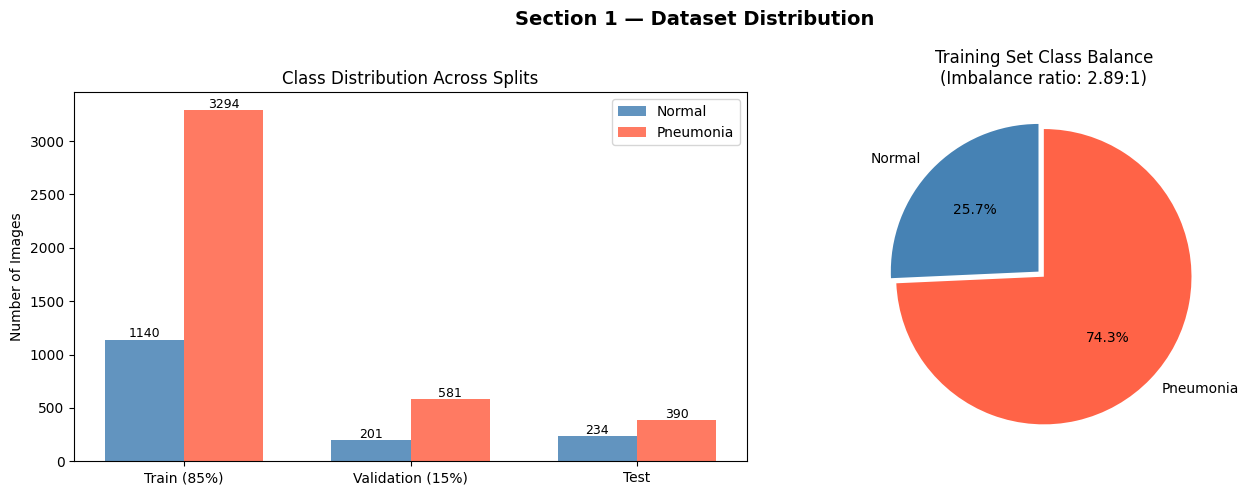

In [17]:
# ── 1. Dataset Distribution ────────────────────────────────────────────────

def count_images(directory):
    counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

total_train = sum(train_counts.values())
val_normal    = int(train_counts.get('NORMAL', 0) * 0.15)
val_pneumonia = int(train_counts.get('PNEUMONIA', 0) * 0.15)
actual_train_normal    = train_counts.get('NORMAL', 0) - val_normal
actual_train_pneumonia = train_counts.get('PNEUMONIA', 0) - val_pneumonia

print("── Dataset Distribution ──")
print(f"\nOriginal Train folder:")
for cls, count in train_counts.items():
    print(f"  {cls}: {count} images")
print(f"\nAfter 85/15 split:")
print(f"  Train  — NORMAL: {actual_train_normal}, PNEUMONIA: {actual_train_pneumonia}, Total: {actual_train_normal + actual_train_pneumonia}")
print(f"  Val    — NORMAL: {val_normal}, PNEUMONIA: {val_pneumonia}, Total: {val_normal + val_pneumonia}")
print(f"\nTest folder:")
for cls, count in test_counts.items():
    print(f"  {cls}: {count} images")

train_normal    = train_counts.get('NORMAL', 0)
train_pneumonia = train_counts.get('PNEUMONIA', 0)
ratio = train_pneumonia / train_normal
print(f"\nClass imbalance ratio (Pneumonia:Normal) = {ratio:.2f}:1")

splits   = ['Train (85%)', 'Validation (15%)', 'Test']
normals  = [actual_train_normal,    val_normal,    test_counts.get('NORMAL', 0)]
pneumos  = [actual_train_pneumonia, val_pneumonia, test_counts.get('PNEUMONIA', 0)]

x = np.arange(len(splits))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - width/2, normals, width, label='Normal',    color='steelblue',  alpha=0.85)
axes[0].bar(x + width/2, pneumos, width, label='Pneumonia', color='tomato',     alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits)
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Class Distribution Across Splits')
axes[0].legend()
for i, (n, p) in enumerate(zip(normals, pneumos)):
    axes[0].text(i - width/2, n + 20, str(n), ha='center', fontsize=9)
    axes[0].text(i + width/2, p + 20, str(p), ha='center', fontsize=9)

axes[1].pie(
    [actual_train_normal, actual_train_pneumonia],
    labels=['Normal', 'Pneumonia'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90,
    explode=(0.05, 0)
)
axes[1].set_title(f'Training Set Class Balance\n(Imbalance ratio: {ratio:.2f}:1)')

plt.suptitle('Section 1 — Dataset Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_01_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 1 - Dataset Distribution

From the graphs above we can see that the dataset has a class imbalance problem. The dataset from (Name) kaggle has specifically more pneumonia images than normal with an imbalance ratio of 2.89:1 which is almost 3 times more pneumonia than normal. This imbalance can probably cause a model towards bias predictions so we need to have this in mind

---

Normal    — Mean size: 1651 × 1319px
Pneumonia — Mean size: 1234 × 853px
All images — Width range: 502–2538px, Height range: 307–2066px


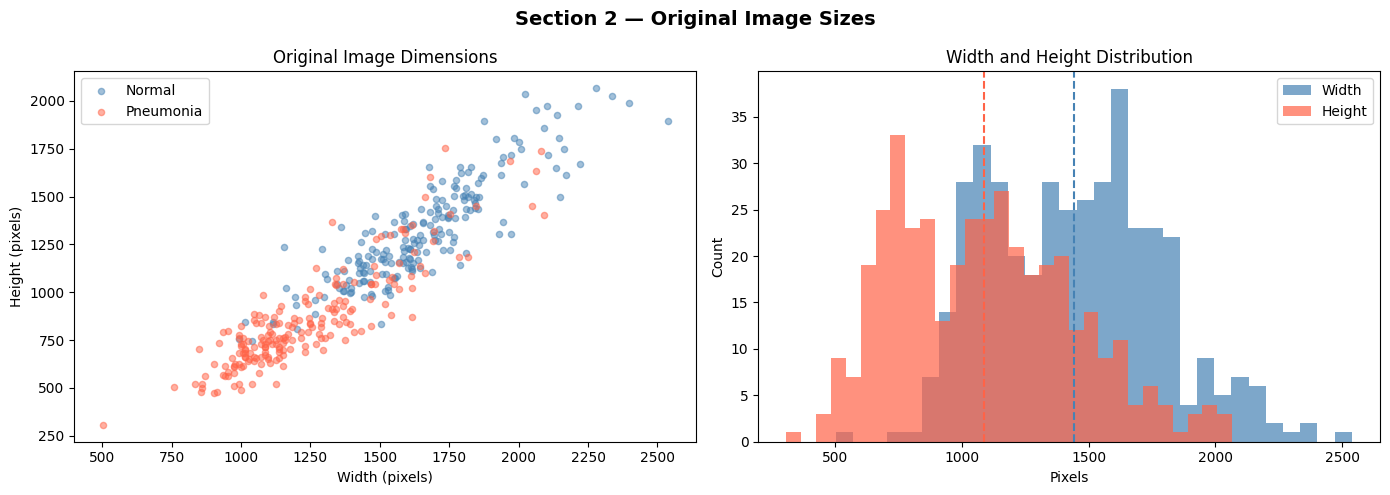

In [18]:
# ── 2. Image Size Distribution ─────────────────────────────────────────────
# Sample up to 200 images per class to check original sizes

def sample_image_sizes(directory, class_name, n_samples=200):
    class_path = os.path.join(directory, class_name)
    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    files = files[:n_samples]
    widths, heights = [], []
    for f in files:
        try:
            img = Image.open(os.path.join(class_path, f))
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except:
            pass
    return widths, heights

normal_w,    normal_h    = sample_image_sizes(TRAIN_DIR, 'NORMAL')
pneumonia_w, pneumonia_h = sample_image_sizes(TRAIN_DIR, 'PNEUMONIA')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(normal_w,    normal_h,    alpha=0.5, color='steelblue', label='Normal',    s=20)
axes[0].scatter(pneumonia_w, pneumonia_h, alpha=0.5, color='tomato',    label='Pneumonia', s=20)
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Height (pixels)')
axes[0].set_title('Original Image Dimensions')
axes[0].legend()

all_w = normal_w + pneumonia_w
all_h = normal_h + pneumonia_h
axes[1].hist(all_w, bins=30, alpha=0.7, color='steelblue', label='Width')
axes[1].hist(all_h, bins=30, alpha=0.7, color='tomato',    label='Height')
axes[1].set_xlabel('Pixels')
axes[1].set_ylabel('Count')
axes[1].set_title('Width and Height Distribution')
axes[1].legend()
axes[1].axvline(np.mean(all_w), color='steelblue', linestyle='--', label=f'Mean width: {np.mean(all_w):.0f}px')
axes[1].axvline(np.mean(all_h), color='tomato',    linestyle='--', label=f'Mean height: {np.mean(all_h):.0f}px')

print(f"Normal    — Mean size: {np.mean(normal_w):.0f} × {np.mean(normal_h):.0f}px")
print(f"Pneumonia — Mean size: {np.mean(pneumonia_w):.0f} × {np.mean(pneumonia_h):.0f}px")
print(f"All images — Width range: {min(all_w)}–{max(all_w)}px, Height range: {min(all_h)}–{max(all_h)}px")

plt.suptitle('Section 2 — Original Image Sizes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_02_image_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 2 - Original Image Sizes

In the graphs above we can see that the original images are not all the same size. We can see the images differ from height to width. For Pneumonia we have a mean size of 1234 × 853px and for Normal we have a mean size of 1651 × 1319px also for all images that were sampled we have a Width range: 502–2538px and a Height range: 307–2066px. That means a smart choice will be to resize all images to the same size (height and width) for better training of the models.

---

Normal    — Mean brightness: 0.4689, Std: 0.0564
Pneumonia — Mean brightness: 0.4797, Std: 0.0679
Brightness difference: 0.0107


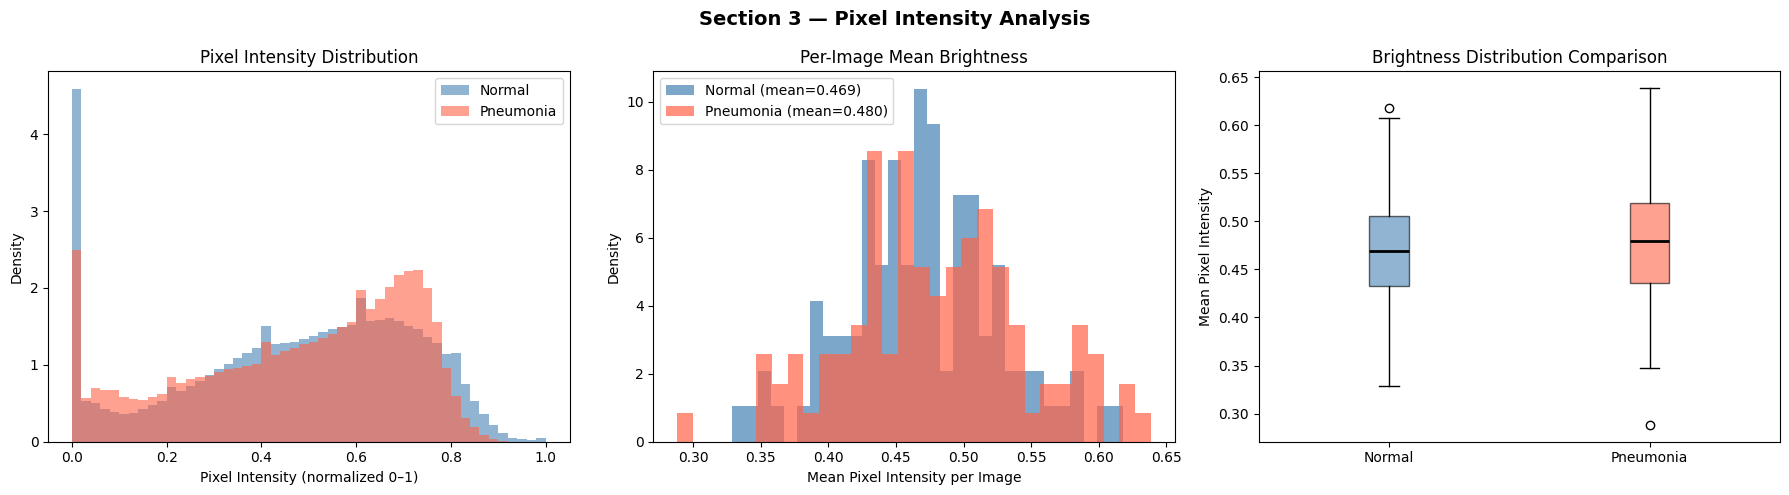

In [19]:
# ── 3. Pixel Intensity Analysis ────────────────────────────────────────────
# Compare pixel brightness distributions between Normal and Pneumonia

def get_pixel_stats(directory, class_name, n_samples=100, size=(150,150)):
    class_path = os.path.join(directory, class_name)
    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    files = files[:n_samples]
    all_pixels = []
    means = []
    for f in files:
        try:
            img = Image.open(os.path.join(class_path, f)).convert('L').resize(size)
            arr = np.array(img) / 255.0
            all_pixels.extend(arr.flatten().tolist())
            means.append(arr.mean())
        except:
            pass
    return np.array(all_pixels), np.array(means)

normal_pixels,    normal_means    = get_pixel_stats(TRAIN_DIR, 'NORMAL')
pneumonia_pixels, pneumonia_means = get_pixel_stats(TRAIN_DIR, 'PNEUMONIA')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(normal_pixels,    bins=50, alpha=0.6, color='steelblue', label='Normal',    density=True)
axes[0].hist(pneumonia_pixels, bins=50, alpha=0.6, color='tomato',    label='Pneumonia', density=True)
axes[0].set_xlabel('Pixel Intensity (normalized 0–1)')
axes[0].set_ylabel('Density')
axes[0].set_title('Pixel Intensity Distribution')
axes[0].legend()

axes[1].hist(normal_means,    bins=30, alpha=0.7, color='steelblue', label=f'Normal (mean={normal_means.mean():.3f})',    density=True)
axes[1].hist(pneumonia_means, bins=30, alpha=0.7, color='tomato',    label=f'Pneumonia (mean={pneumonia_means.mean():.3f})', density=True)
axes[1].set_xlabel('Mean Pixel Intensity per Image')
axes[1].set_ylabel('Density')
axes[1].set_title('Per-Image Mean Brightness')
axes[1].legend()

axes[2].boxplot(
    [normal_means, pneumonia_means],
    labels=['Normal', 'Pneumonia'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)
axes[2].set_ylabel('Mean Pixel Intensity')
axes[2].set_title('Brightness Distribution Comparison')
colors = ['steelblue', 'tomato']
for patch, color in zip(axes[2].patches, colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

print(f"Normal    — Mean brightness: {normal_means.mean():.4f}, Std: {normal_means.std():.4f}")
print(f"Pneumonia — Mean brightness: {pneumonia_means.mean():.4f}, Std: {pneumonia_means.std():.4f}")
print(f"Brightness difference: {abs(normal_means.mean() - pneumonia_means.mean()):.4f}")

plt.suptitle('Section 3 — Pixel Intensity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_03_pixel_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Pixel Intensity Analysis

In the graphs we can see that the brightness difference between Normal and Pneumonia is minimal. Normal averages 0.4689 and Pneumonia 0.4797. This is a really small gap of just 0.0107. That means Brightness alone is not a reliable discriminator. We can also see that Pneumonia images have higher variance. Std of 0.0679 for Pneumonia and 0.0564 for Normal. Pneumonia scans are more inconsistent in exposure, likely reflecting a wider mix of disease severities and imaging conditions. The pixel intensity distribution skews dark for both classes. The Pixel Intensity Distribution plot shows a strong peak near 0 (dark pixels), consistent with chest X-rays where most of the image is black background. Normal images have a slightly more pronounced high-intensity tail (brighter lung fields).

---

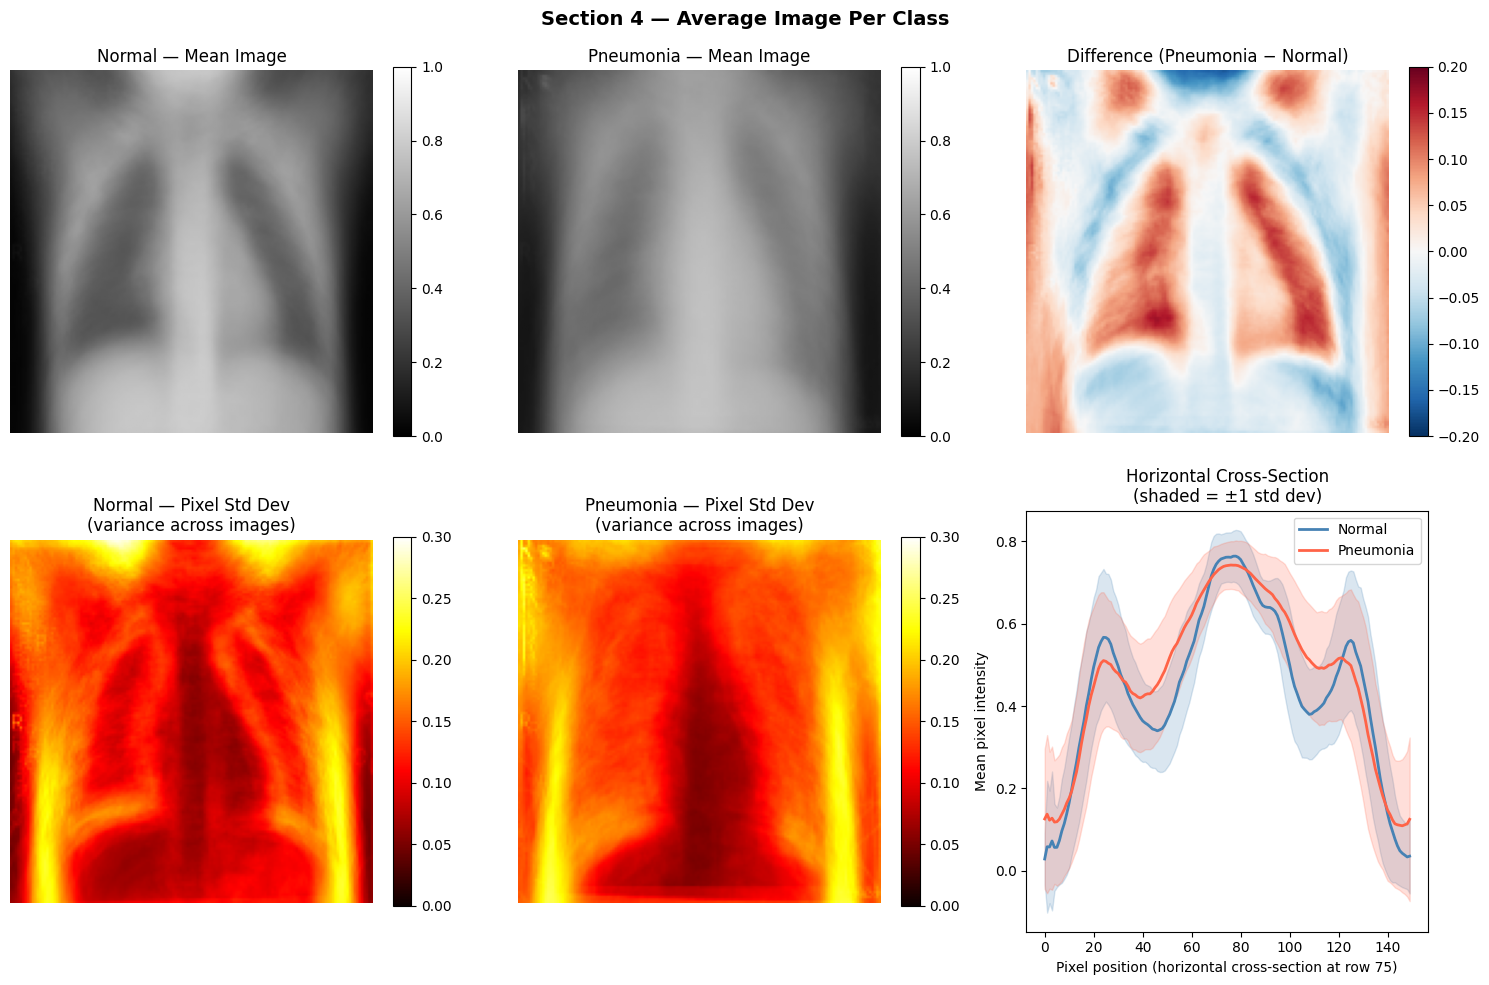

In [20]:
# ── 4. Average Image Per Class ─────────────────────────────────────────────

def compute_mean_image(directory, class_name, n_samples=200, size=(150,150)):
    class_path = os.path.join(directory, class_name)
    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    files = files[:n_samples]
    stack = []
    for f in files:
        try:
            img = Image.open(os.path.join(class_path, f)).convert('L').resize(size)
            stack.append(np.array(img) / 255.0)
        except:
            pass
    return np.mean(stack, axis=0), np.std(stack, axis=0)

normal_mean_img,    normal_std_img    = compute_mean_image(TRAIN_DIR, 'NORMAL')
pneumonia_mean_img, pneumonia_std_img = compute_mean_image(TRAIN_DIR, 'PNEUMONIA')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

im1 = axes[0][0].imshow(normal_mean_img,    cmap='gray', vmin=0, vmax=1)
axes[0][0].set_title('Normal — Mean Image', fontsize=12)
axes[0][0].axis('off')
plt.colorbar(im1, ax=axes[0][0], fraction=0.046)

im2 = axes[0][1].imshow(pneumonia_mean_img, cmap='gray', vmin=0, vmax=1)
axes[0][1].set_title('Pneumonia — Mean Image', fontsize=12)
axes[0][1].axis('off')
plt.colorbar(im2, ax=axes[0][1], fraction=0.046)

diff = pneumonia_mean_img - normal_mean_img
im3 = axes[0][2].imshow(diff, cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[0][2].set_title('Difference (Pneumonia − Normal)', fontsize=12)
axes[0][2].axis('off')
plt.colorbar(im3, ax=axes[0][2], fraction=0.046)

im4 = axes[1][0].imshow(normal_std_img,    cmap='hot', vmin=0, vmax=0.3)
axes[1][0].set_title('Normal — Pixel Std Dev\n(variance across images)', fontsize=12)
axes[1][0].axis('off')
plt.colorbar(im4, ax=axes[1][0], fraction=0.046)

im5 = axes[1][1].imshow(pneumonia_std_img, cmap='hot', vmin=0, vmax=0.3)
axes[1][1].set_title('Pneumonia — Pixel Std Dev\n(variance across images)', fontsize=12)
axes[1][1].axis('off')
plt.colorbar(im5, ax=axes[1][1], fraction=0.046)

axes[1][2].plot(normal_mean_img[75, :],    color='steelblue', label='Normal',    linewidth=2)
axes[1][2].plot(pneumonia_mean_img[75, :], color='tomato',    label='Pneumonia', linewidth=2)
axes[1][2].fill_between(range(150),
    normal_mean_img[75, :] - normal_std_img[75, :],
    normal_mean_img[75, :] + normal_std_img[75, :],
    alpha=0.2, color='steelblue')
axes[1][2].fill_between(range(150),
    pneumonia_mean_img[75, :] - pneumonia_std_img[75, :],
    pneumonia_mean_img[75, :] + pneumonia_std_img[75, :],
    alpha=0.2, color='tomato')
axes[1][2].set_xlabel('Pixel position (horizontal cross-section at row 75)')
axes[1][2].set_ylabel('Mean pixel intensity')
axes[1][2].set_title('Horizontal Cross-Section\n(shaded = ±1 std dev)')
axes[1][2].legend()

plt.suptitle('Section 4 — Average Image Per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_04_mean_images.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 - Average Image Per Class


The lung fields are the primary discriminating region. The difference map (Pneumonia − Normal) shows strong red (positive) areas over the lungs and blue (negative) around the heart/mediastinum. Pneumonia images are brighter in lung tissue — consistent with consolidation and infiltrates filling air spaces. Normal lungs are darker (more air-filled) and more defined. The mean Normal image shows a clearer cardiac silhouette and darker, well-aerated lung fields. The Pneumonia mean is hazier overall, with less structural contrast. Pneumonia has higher pixel-level variance. The std dev heatmaps show more yellow/white (high variance) spread across the lung region in Pneumonia and less in Normal. This reflects the heterogeneity of pneumonia presentations. The cross-section confirms the lung-region signal. At row 75 (mid-thorax), Normal peaks higher at the lung edges (~0.75) while Pneumonia is elevated in the central regions. The wider Pneumonia confidence band reinforces its greater within-class variability.

---

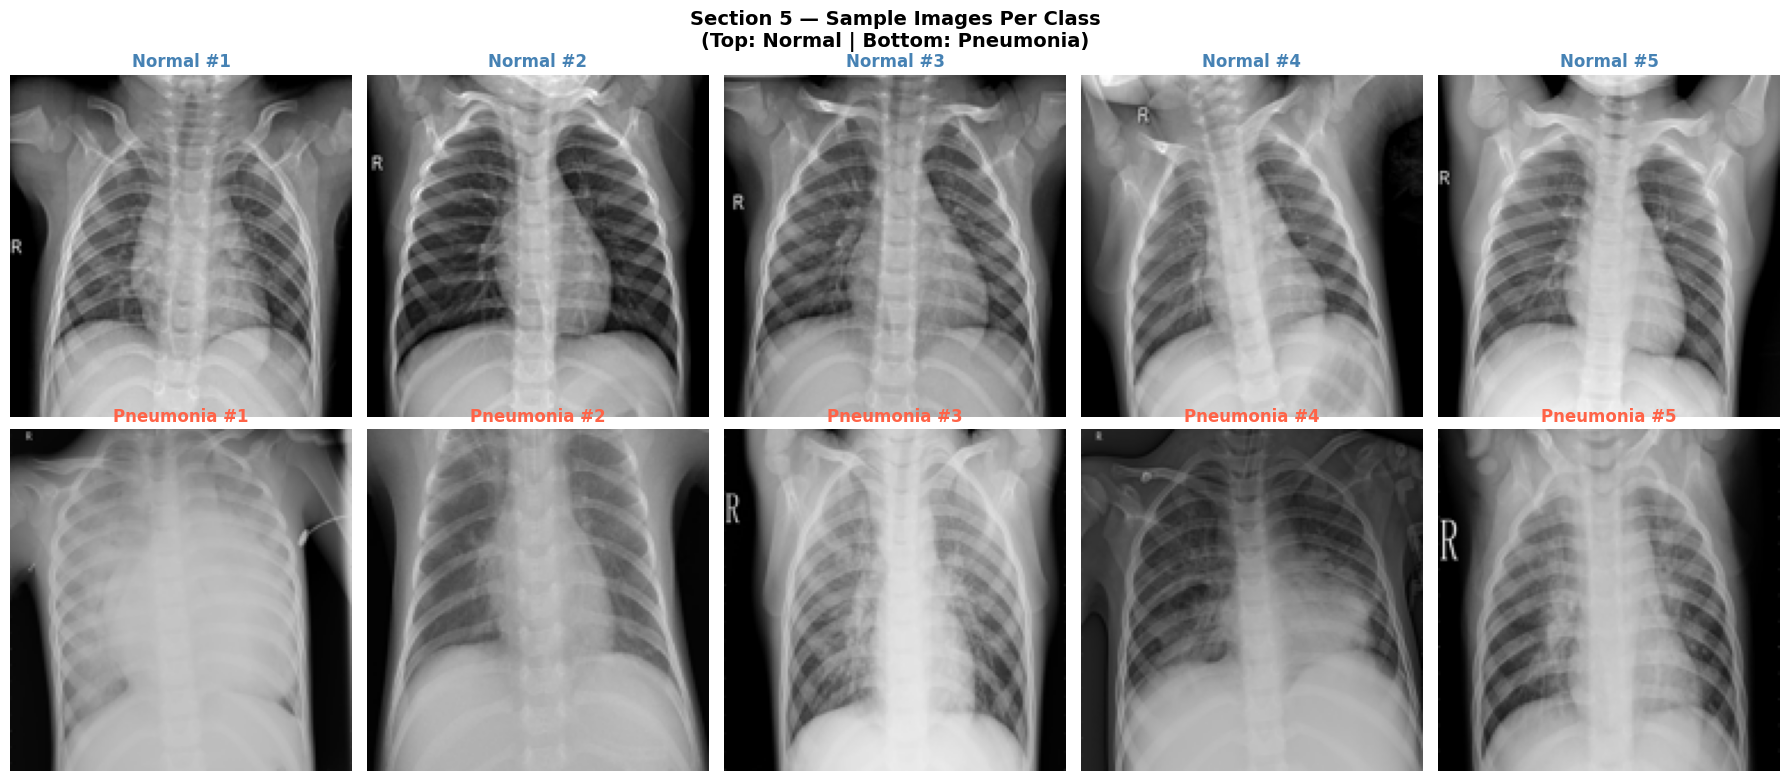

In [21]:
# ── 5. Sample Images Side by Side ──────────────────────────────────────────

def load_sample_images(directory, class_name, n=5, size=(150,150)):
    class_path = os.path.join(directory, class_name)
    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    np.random.seed(SEED)
    selected = np.random.choice(files, n, replace=False)
    images = []
    for f in selected:
        try:
            img = Image.open(os.path.join(class_path, f)).convert('RGB').resize(size)
            images.append(np.array(img))
        except:
            pass
    return images

normal_samples    = load_sample_images(TRAIN_DIR, 'NORMAL',    n=5)
pneumonia_samples = load_sample_images(TRAIN_DIR, 'PNEUMONIA', n=5)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, img in enumerate(normal_samples):
    axes[0][i].imshow(img, cmap='gray')
    axes[0][i].set_title(f'Normal #{i+1}', color='steelblue', fontweight='bold')
    axes[0][i].axis('off')

for i, img in enumerate(pneumonia_samples):
    axes[1][i].imshow(img, cmap='gray')
    axes[1][i].set_title(f'Pneumonia #{i+1}', color='tomato', fontweight='bold')
    axes[1][i].axis('off')

plt.suptitle('Section 5 — Sample Images Per Class\n(Top: Normal | Bottom: Pneumonia)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_05_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 - Sample Images Per Class

Here i provide 5 Normal and 5 Pneumonia images side by side for visual comparison. We can see that the Pneumonia chest X-Rays tend to be more hazy than the Normal ones as expected.

---

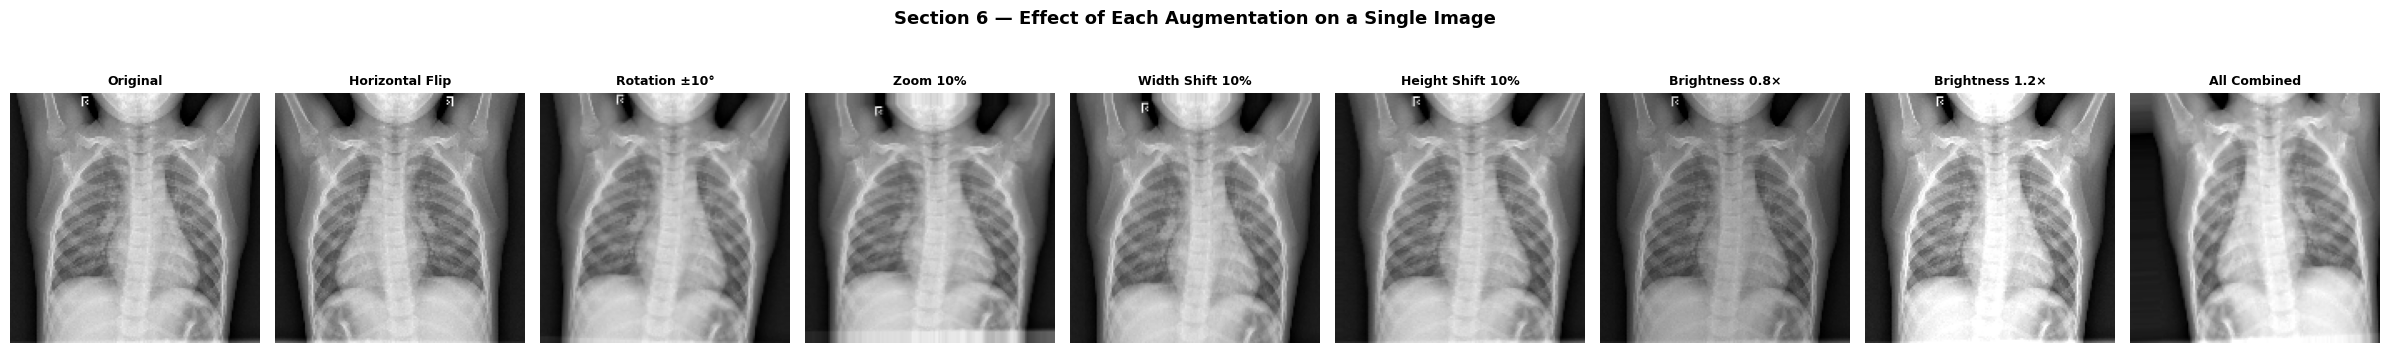

In [22]:
# ── 6. Augmentation Visualization ──────────────────────────────────────────

from tensorflow.keras.preprocessing.image import load_img, img_to_array

sample_path = os.path.join(TRAIN_DIR, 'NORMAL')
sample_file = os.listdir(sample_path)[0]
sample_img  = load_img(os.path.join(sample_path, sample_file), target_size=(150, 150))

sample_arr = img_to_array(sample_img)           
sample_arr = np.expand_dims(sample_arr, axis=0)

augmentations = [
    ('Original',         ImageDataGenerator()),
    ('Horizontal Flip',  ImageDataGenerator(horizontal_flip=True)),
    ('Rotation ±10°',    ImageDataGenerator(rotation_range=10)),
    ('Zoom 10%',         ImageDataGenerator(zoom_range=0.1)),
    ('Width Shift 10%',  ImageDataGenerator(width_shift_range=0.1)),
    ('Height Shift 10%', ImageDataGenerator(height_shift_range=0.1)),
    ('Brightness 0.8×',  ImageDataGenerator(brightness_range=[0.8, 0.8])),
    ('Brightness 1.2×',  ImageDataGenerator(brightness_range=[1.2, 1.2])),
    ('All Combined',     ImageDataGenerator(
                             horizontal_flip=True,
                             rotation_range=10,
                             zoom_range=0.1,
                             width_shift_range=0.1,
                             height_shift_range=0.1,
                             brightness_range=[0.8, 1.2]
                         )),
]

fig, axes = plt.subplots(1, len(augmentations), figsize=(24, 4))

for ax, (title, gen) in zip(axes, augmentations):
    it  = gen.flow(sample_arr, batch_size=1, seed=SEED)
    aug = next(it)[0]
    
    aug = np.clip(aug, 0, 255).astype(np.uint8)
    
    ax.imshow(aug, cmap='gray')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle('Section 6 — Effect of Each Augmentation on a Single Image',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_06_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()

# Section 6 — Augmentation Strategy

## Augmentations Applied

| Transform | Parameter | Rationale |
|---|---|---|
| Horizontal Flip | — | Chest X-rays can be mirrored without losing clinical meaning |
| Rotation | ±10° | Mimics slight patient positioning differences |
| Zoom | 10% | Simulates variable distance to detector |
| Width / Height Shift | 10% | Accounts for off-center patient positioning |
| Brightness | 0.8× – 1.2× | Reflects exposure variability across machines |
| **All Combined** | all of the above | The actual training augmentation pipeline |

## What the Visuals Confirm

Each individual transform is **subtle and clinically plausible** — anatomy stays intact, the lung structure remains recognizable. The combined version looks like a naturally acquired X-ray variant, not an artificially distorted image.

---